## **1. Introduction**
The goal of this notebook is to estimate a CNN model

## **2. Libraries**

In [1]:
# Standard
import os
import sys
import warnings
import pandas as pd
import numpy as np

# Image
import cv2
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Tensor Flow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from tqdm.auto import tqdm

2025-05-25 06:53:57.097573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748156037.280365      18 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748156037.336747      18 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## **3. Utils**

In [2]:
def image_path_generation(row, base_path='/wmdd811k/images'):
    """
    Generate the full path to an image based on the dataset split and image name.

    Parameters:
    - row (pd.Series): A row with at least 'set' and 'image' fields.
    - base_path (str): The base directory containing the image folders.

    Returns:
    - str: Full path to the image file.
    """
    subfolder = row['set']
    return os.path.join(base_path, subfolder, row['image'])

# Plot the label distribution as a bar chart
def plot_label_distribution(df, label_col='labels', title='Label Distribution',
                            figsize=(6, 4), color_palette='Set2'):
    """
    Plot a bar chart of label distribution with annotations and full grid.

    Parameters:
    - df (pd.DataFrame): DataFrame containing the label column.
    - label_col (str): Name of the column containing the labels.
    - title (str): Title of the plot.
    - figsize (tuple): Size of the figure (width, height).
    - color_palette (str or list): Color palette for the bars.
    """
    counts = df[label_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    ax = plt.bar(counts.index.astype(str), counts.values, color=sns.color_palette(color_palette, len(counts)))

    # Annotate each bar with its count
    for index, value in enumerate(counts.values):
        plt.text(index, value + (0.00 * counts.max()), f'{value}',
                 ha='center', va='bottom', fontsize=8)

    plt.title(title, fontsize=13)
    plt.xlabel('Labels', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, axis='both', linestyle='--', linewidth=0.5, alpha=0.8)  # Full grid
    plt.tight_layout()
    plt.show()

# Define function to compute ROC AUC score per class in a one-vs-all manner
def roc_auc_score_multiclass(actual_class, pred_class):
    unique_classes = set(actual_class)
    roc_auc_dict = {}
    for cls in unique_classes:
        binary_actual = [1 if x == cls else 0 for x in actual_class]
        binary_pred = [1 if x == cls else 0 for x in pred_class]
        try:
            roc_auc = roc_auc_score(binary_actual, binary_pred)
        except ValueError:
            roc_auc = float('nan')  # Handle case with no positive samples
        roc_auc_dict[cls] = roc_auc
    return roc_auc_dict


## **4. CNN Utils**

In [3]:
def load_images(dataframe, cfg):
    """Load and preprocess grayscale images from a dataframe with progress bar."""
    images = []
    labels = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading images"):
        img_path = row['image_id']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            continue
        
        img = cv2.resize(img, (cfg.input_shape[0], cfg.input_shape[1]))
        img = img.astype(np.float32)
        
        if cfg.normalize:
            img /= 255.0
        
        img = np.expand_dims(img, axis=-1)
        images.append(img)
        labels.append(row['labels'])

    return np.array(images), np.array(labels)

def get_class_weights(y_train):
    """Compute class weights to handle imbalance."""
    unique_classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
    return {i: weight for i, weight in zip(unique_classes, class_weights)}


# Define and compile a CNN model
def build_model(input_shape, num_classes):
    model = keras.models.Sequential([
        layers.Conv2D(64, 7, strides=(2,2), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


def plot_history(history):
    """Plot training and validation loss and accuracy"""
    
    # Recupera i dati dal training
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    train_acc = history.history.get('accuracy')  # 'accuracy' per classificazione
    val_acc = history.history.get('val_accuracy')

    epochs = range(1, len(train_loss) + 1)

    # Plot della Loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plot dell'Accuracy (se disponibile)
    if train_acc is not None and val_acc is not None:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
        plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title('Training and Validation Accuracy')

    plt.show()

def train_model(model, X_train, y_train, X_val, y_val, use_class_weights=True):
    class_weights = get_class_weights(y_train) if use_class_weights else None

    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=cfg.patience, restore_best_weights=True)]
    
    if cfg.model_save:
        model_path = os.path.join(cfg.output_dir, "CNN_best_model.keras")
        callbacks.append(keras.callbacks.ModelCheckpoint(model_path, save_best_only=True))
    
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=cfg.epochs,
                        batch_size=cfg.batch_size,
                        class_weight=class_weights,
                        callbacks=callbacks)
    plot_history(history)
    
    return history

def load_trained_model(model_dir, model_name):
    
    model_path = os.path.join(model_dir, model_name)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f" Model not found: {model_path}")
    
    model = keras.models.load_model(model_path)
    print(f" Model successfully loaded from {model_path}")
    
    return model


def predict_test(model, test_dataframe, batch_size=32):
    predictions = []
    batch_images = []
    
    for _, row in tqdm(test_dataframe.iterrows(), total=len(test_dataframe), desc="Predizione", ncols=100):
        img_path = row['image_id']  
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
        
        if img is None:
            predictions.append(None)
            continue
        
        img = cv2.resize(img, (cfg.input_shape[0], cfg.input_shape[1]))  # Resize
        img = img.astype(np.float32)  # Converti in float
        
        if CFG.normalize:
            img /= 255.0  # Normalizza
        
        img = np.expand_dims(img, axis=-1)  # Aggiungi canale (H, W, 1)
        img = np.expand_dims(img, axis=0)  # Aggiungi batch dimension (1, H, W, C)
        
        batch_images.append(img)
        
        if len(batch_images) == batch_size:
            batch_imgs = np.concatenate(batch_images, axis=0)
            batch_preds = model.predict(batch_imgs)
            predictions.extend(np.argmax(batch_preds, axis=1))  
            batch_images = []  # Reset del batch
    
    if batch_images:
        batch_imgs = np.concatenate(batch_images, axis=0)
        batch_preds = model.predict(batch_imgs)
        predictions.extend(np.argmax(batch_preds, axis=1))
    
    return np.array(predictions)

## **5. Load dataset**

In [4]:
# Define the base path for images
dataseet_path = '/kaggle/input/wm811k-images-dataset/images/'
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataseet_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataseet_path), axis=1)

df.shape

(10860, 7)

In [5]:
# Split the main DataFrame into separate datasets: train, val, test
datasets = {}
for split in ['train', 'val', 'test']:
    subset = df[df['set'] == split].reset_index(drop=True)
    datasets[split] = subset
    print(f"{split} shape: {subset.shape}")

# Assign individual datasets for easier access
train = datasets['train']
valid = datasets['val']
test = datasets['test']

# Drop unnecessary columns from each dataset
cols_to_drop = ['wf_id', 'dieSize', 'lotid', 'image', 'set']
train = train.drop(cols_to_drop, axis=1)
valid = valid.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)

train shape: (5907, 7)
val shape: (1304, 7)
test shape: (2172, 7)


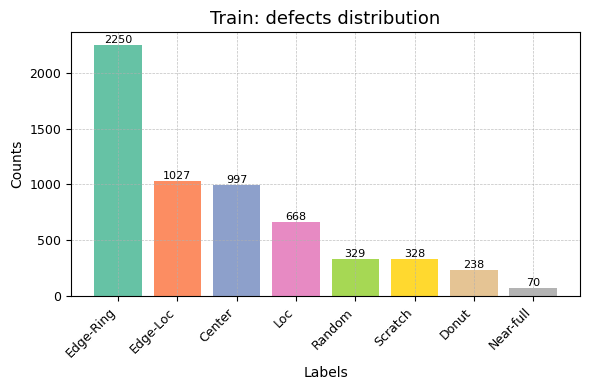

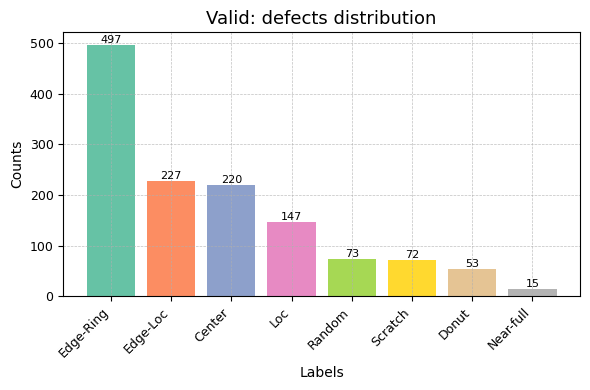

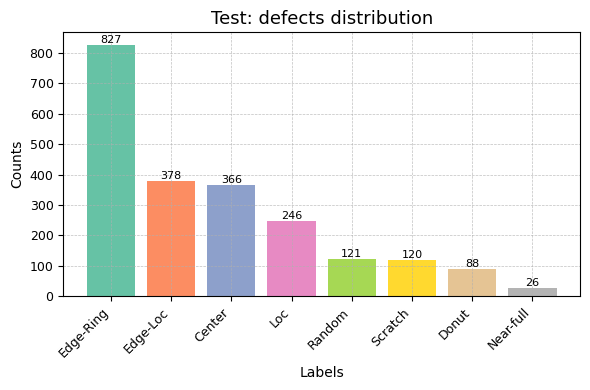

In [6]:
plot_label_distribution(train, label_col='labels', title='Train: defects distribution')
plot_label_distribution(valid, label_col='labels', title='Valid: defects distribution')
plot_label_distribution(test, label_col='labels', title='Test: defects distribution')

In [7]:
# labels encoding
label2int = {
    'Center': 0,
     'Donut': 1,
     'Edge-Loc': 2,
     'Edge-Ring': 3,
     'Loc': 4,
     'Random': 5,
     'Scratch': 6,
     'Near-full': 7}

train['labels']=train.labels.map(label2int)
valid['labels']=valid.labels.map(label2int)
test['labels']=test.labels.map(label2int)

print(np.sort(train['labels'].unique()))
print(np.sort(valid['labels'].unique()))
print(np.sort(test['labels'].unique()))

[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]


## **6. Configuration**

In [8]:
class CFG:
    epochs = 200  # Reduced from 500, sufficient for CNN on 101x101 images
    patience = 20  # More balanced value to stop earlier in case of overfitting
    normalize = True  
    model_save = True  # Automatically save the best model
    num_classes = 8  
    input_shape = (101, 101, 1)  
    batch_size = 64  # Larger batch size if possible, to speed up training
    output_dir = './'#directory to save the model 
cfg = CFG()

os.makedirs(cfg.output_dir, exist_ok=True)

## **7. Model training**

<class 'numpy.ndarray'>
(404, 404, 3)
<class 'numpy.ndarray'>
(404, 404, 3)


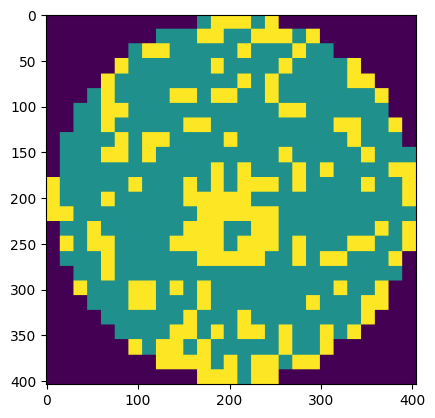

In [9]:
sample_image = cv2.imread(train.iloc[0]['image_id'])
print(type(sample_image))
print(sample_image.shape)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
print(type(sample_image))
print(sample_image.shape)
plt.imshow(sample_image)

### **7.1 Build and compile the model**

In [10]:
model = build_model(cfg.input_shape, cfg.num_classes)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # accepts integer labels
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748156050.238385      18 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 51, 51, 64)          │           3,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 51, 51, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 25, 25, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 25, 25, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 25, 25, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 25, 25, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,359,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,2

 Total params: 3,514,440 (13.41 MB)

 Trainable params: 3,512,776 (13.40 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [11]:
model = build_model(cfg.input_shape, cfg.num_classes)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # accepts integer labels
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 51, 51, 64)          │           3,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 51, 51, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 25, 25, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 25, 25, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 25, 25, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 25, 25, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       2,359,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,2

 Total params: 3,514,440 (13.41 MB)

 Trainable params: 3,512,776 (13.40 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [12]:
(X_train, y_train) = load_images(train,cfg)
(X_val, y_val) = load_images(valid,cfg)
print('X train lenght:', len(X_train))
print('Y train lenght:', len(y_train))
print('X valid lenght:', len(X_val))
print('Y valid lenght:', len(y_val))

Loading images:   0%|          | 0/5907 [00:00<?, ?it/s]

Loading images:   0%|          | 0/1304 [00:00<?, ?it/s]

X train lenght: 5907
Y train lenght: 5907
X valid lenght: 1304
Y valid lenght: 1304


Epoch 1/200


I0000 00:00:1748156114.982494      61 service.cc:148] XLA service 0x7b720001ae60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748156114.983109      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748156115.619727      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


11/93 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1605 - loss: 7.6334

I0000 00:00:1748156121.113043      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.1768 - loss: 4.7434 - val_accuracy: 0.0115 - val_loss: 2.9372
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1162 - loss: 2.0467 - val_accuracy: 0.0115 - val_loss: 3.1952
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2117 - loss: 1.9565 - val_accuracy: 0.0353 - val_loss: 2.2199
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2824 - loss: 1.9603 - val_accuracy: 0.3811 - val_loss: 3.0619
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3152 - loss: 1.9712 - val_accuracy: 0.3865 - val_loss: 2.4156
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4009 - loss: 1.8327 - val_accuracy: 0.4225 - val_loss: 1.3976
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4293 - loss: 1.8239 - val_accuracy: 0.2285 - val_loss: 2.2050
Epoch 8/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4062 - loss: 1.9233 - val_accuracy: 0.3390 - val_

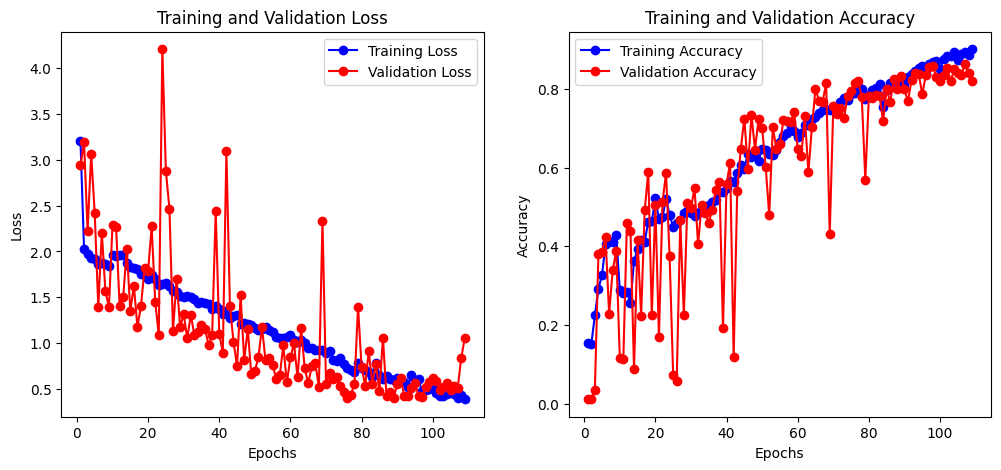

In [13]:
#train_model(model, X_train, y_train, X_val, y_val, cfg, use_class_weights=True)
train_model(model, X_train, y_train, X_val, y_val, cfg)

## **8. Test evaluation**

In [14]:
model_dir = cfg.output_dir
model_name ='CNN_best_model.keras'

# Carica il modello
model = load_trained_model(model_dir,model_name)
test_predictions = predict_test(model, test, cfg)


 Model successfully loaded from ./CNN_best_model.keras


Predizione:   0%|                                                          | 0/2172 [00:00<?, ?it/s]

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [15]:
# Add predictions to the test DataFrame
test['preds'] = test_predictions

# Extract class labels and their corresponding IDs
labels = list(label2int.keys())
labels_id = list(label2int.values())
#print("Label IDs:", labels_id)

# Ground truth and predicted labels
y_true = test['labels']
y_pred = test['preds']

# Print overall accuracy and macro F1-score
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print(f"Macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.3f}")

# Labeling
#----------------------------------------------------------------------------------
labels = list(label2int.keys())
int2label = {v: k for k, v in label2int.items()}


# Compute ROC AUC per class and map them to their labels
roc_auc_raw = roc_auc_score_multiclass(y_true, y_pred)
roc_auc_named = {int2label[k]: round(v, 2) for k, v in roc_auc_raw.items()}

# Print ROC AUC scores for each class
print('----------------------------------------')
print("ROC AUC for each class:")
for label, score in roc_auc_named.items():
    print(f"{label}: {score}")

Overall Accuracy: 0.823
Macro F1 Score: 0.665
----------------------------------------
ROC AUC for each class:
Center: 0.96
Donut: 0.99
Edge-Loc: 0.89
Edge-Ring: 0.98
Loc: 0.75
Random: 0.58
Scratch: 0.78
Near-full: 0.98
